# STALE - every output below predates the 2026-08/09 corrections

**Do not cite any number rendered in this notebook.** The committed cell outputs were
produced before:

1. the five world-model fixes of 2026-08-28/30 (observation clipping, always-firing
   gradient clip, unenforced max-red bound, reward scale, lane apportionment), and
2. preregistration amendments **A1-A4** (2026-09-01), which changed the unit of analysis,
   the eval-seed count (5 -> 15), the censoring rule and the imputation scale.

Both the statistics and the world that generated them have since changed. Re-run the
campaign and re-execute this notebook top-to-bottom before using it as the §9 deliverable.
See `data/eval/_STALE_eval_results_README.md` and the Amendments section of
`preregistration.md`.


# Final Evaluation — Statistical Analysis (T-04-02 / T-04-03)

Smart-Traffic-RL capstone. This is the single committed analysis notebook required by
`preregistration.md` §9: *"All tests, corrections, effect sizes, and plots are produced by a
single committed analysis notebook (`analysis/final_eval.ipynb`), runnable via `make eval-final`."*

It is intentionally thin: every number and every plot below is produced by
`scripts/build_analysis.py` (imported, not reimplemented), which in turn reuses the LOCKED
statistical core in `scripts/analyze_eval.py` (`_series`, `_wilcoxon`, `_holm`, ...) **unmodified**.
This notebook's job is narrative — state the pre-registered rules before showing any number, and
never re-derive a statistic the module already computed.

## The locked statistical protocol (`preregistration.md`, frozen 2026-06-24)

- **Test:** two-sided Wilcoxon signed-rank, paired, `zero_method="pratt"`, **α = 0.05**. `*` marks
  p < 0.05, `**` marks p < 0.01 — **0.05 is the decision bar**.
- **Effect size:** median paired difference + bootstrap 95% CI, **B=2000, numpy `default_rng(0)`**
  — this is the actual seed/bootstrap provenance the committed `_wilcoxon` uses. Not seed 42,
  regardless of what any other note says; §5 of the pre-registration fixes B and the method, not a
  seed.
- **Unit of analysis:** `cell = (algorithm, scenario, training_seed)` → 5 eval episodes → **n=15**
  per metric (training seeds {42, 123, 2024} × 5 eval episodes). Pairing is within the same eval
  episode / SUMO vehicle seed — this is load-bearing.
- **The locked 7 KPIs** (better direction in parentheses): avg waiting time (lower), avg queue
  length (lower), throughput (higher), number of stops (lower), fairness std of per-movement wait
  (lower), worst-movement max wait (lower), P95 waiting time (lower). **Headline KPIs: avg wait,
  throughput, worst-movement max wait.**
- **Three SEPARATE Holm–Bonferroni families, all on the designated test scenario SCN-05** (never
  pooled into one family of 35):
  - **C1 (H1):** `dqn-hybrid` vs each of {webster, max_pressure, actuated} × 7 KPIs = **21**
    hypotheses.
  - **C2 (H2):** `dqn-hybrid` vs `dqn-plain` (the headline forecast ablation) × 7 KPIs = **7**
    hypotheses.
  - **C3 (H3):** `dqn-hybrid` vs `dqn-random-lstm` × 7 KPIs = **7** hypotheses.
- **SCN-01..04 are SUPPORTING / EXPLORATORY:** raw p-values, no family correction claimed, and
  every null is written as **"no effect detected at n=15"**, never "no effect".
- **Censoring rule (§8), quoted verbatim:** *"Censored cells are excluded from the paired test for
  the affected KPI only if censored for all algorithms in the pair, and the exclusion is
  reported."* Operationally: a pair is dropped only when BOTH rows have `gridlock_censored == 1`
  (or either KPI value is missing) — exactly what `_series()` does. Every drop is counted and
  reported below.
- **Webster N/A rule (§8):** when a scenario's flow ratio Y ≥ 1.00, Webster is infeasible and
  reported as "Webster N/A (Y=…)" with the named `FixedTime-120` fallback substituted — never
  blanked or silently dropped.
- **Missing pair member (§8):** if an algorithm has no KPI for a given eval seed, that paired
  sample is dropped from that KPI's test and the drop is reported (count + reason). The test is
  never run on unpaired/reshuffled samples.
- **Honest-reporting rules (§4), binding:** non-significant differences are reported as
  **parity**, never re-framed as a win. Worst-movement max wait and forecast MSE are reported even
  if embarrassing. Failed ablations stay in.

**Hard project rule:** per-scenario × per-seed numbers are always shown before any aggregate.
Aggregating across scenarios or seeds and leading with the mean is a scar this project has been
burned by four separate times.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("could not locate repo root (pyproject.toml not found)")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 60)

print(f"repo root: {REPO_ROOT}")

repo root: C:\Year3\smart-traffic-rl


## Run the analysis module

`scripts/build_analysis.py` is the separable, importable analysis+plotting module (T-04-02's DoD:
"the plotting/table-generation code is a separable module" — a plotting break at write-up time has
a recovery path, not a buried notebook blob). `main()` writes every T1–T4 / P1–P5 / sel-plain /
confirmatory-family table into `data/eval/analysis/`. Everything shown below in this notebook is
then re-derived from the SAME pure `build_*` functions, so the notebook's numbers and the on-disk
artifacts can never silently drift apart.

In [2]:
from scripts.build_analysis import (
    ALGO_LABELS,
    DEPLOYED_LSTM_VERSION,
    HEADLINE_VARIANTS,
    ROW_ORDER,
    TEST_SCENARIO,
    build_confirmatory_family,
    build_family_c1,
    build_family_c2,
    build_family_c3,
    build_honest_findings,
    build_sel_plain_table,
    build_supporting_regime,
    build_t1_main_results,
    build_t2_ablation_results,
    build_t3_lstm_standalone,
    build_t4_wallclock_budget,
    build_webster_feasibility,
    load_rows,
    main as build_all,
)

build_all()  # writes every artifact to data/eval/analysis/ (idempotent, safe to re-run)
_OUT_DIR = REPO_ROOT / "data" / "eval" / "analysis"
print("wrote all artifacts to", _OUT_DIR.relative_to(REPO_ROOT))

[build_analysis] wrote all T1-T4 / P1-P5 / sel-plain / family tables to data\eval\analysis
wrote all artifacts to data\eval\analysis


## Data

`data/eval/eval_results.csv` — 300 evaluation episodes (5 scenarios × 12 algo-conditions × 5 eval
seeds). The 9 headline DQN training runs are `{plain,hybrid,random-lstm}_seed{42,123,2024}`; every
other `runs/*` directory (`iqn*`, `*-bc`, `*-grid`, `*-shift`, `hybrid-boot*`, `*_seed7`,
`*_smoke`, `sanity_*`) is a falsified side-experiment and is excluded from every table/plot below
unless explicitly noted otherwise (P1/P2/P5 use `runs/*` directly; T1-T4 use the CSV).

In [3]:
rows = load_rows()
scenarios = sorted({r["scenario"] for r in rows})
algos = sorted({r["variant"] or r["algo"] for r in rows})
n_censored = sum(int(r["gridlock_censored"]) for r in rows)
print(f"n rows = {len(rows)}")
print(f"scenarios = {scenarios}")
print(f"algo/variant keys = {algos}")
print(f"gridlock-censored rows = {n_censored}/{len(rows)} ({100*n_censored/len(rows):.1f}%)")

n rows = 300
scenarios = ['SCN-01', 'SCN-02', 'SCN-03', 'SCN-04', 'SCN-05']
algo/variant keys = ['actuated', 'hybrid', 'max_pressure', 'plain', 'random-lstm', 'webster']
gridlock-censored rows = 173/300 (57.7%)


## Webster feasibility check (§8 N/A rule)

Does a Webster-N/A / `FixedTime-120` case actually occur in this data (Y ≥ 1.00)? Checked against
the real scenario definitions — not fabricated.

In [4]:
wf = build_webster_feasibility()
display(wf)
print()
if wf["webster_na"].any():
    print("Webster N/A occurs for:", wf.loc[wf["webster_na"], "scenario"].tolist())
else:
    print("No Webster-N/A case exists in this data: every scenario in eval_results.csv has "
          "Y < 0.90 (in fact all 5 are 'normal', not even 'degraded'). The FixedTime-120 fallback "
          "path is implemented (src/baselines/webster.py) but never exercised by these 5 scenarios.")

,scenario,flow_ratio_Y,status,cycle_s,webster_na
0,SCN-01,0.177778,normal,56.000000,False
1,SCN-02,0.533333,normal,70.607143,False
2,SCN-03,0.533333,normal,70.607143,False
3,SCN-04,0.377778,normal,64.904412,False
4,SCN-05,0.533333,normal,70.607143,False



No Webster-N/A case exists in this data: every scenario in eval_results.csv has Y < 0.90 (in fact all 5 are 'normal', not even 'degraded'). The FixedTime-120 fallback path is implemented (src/baselines/webster.py) but never exercised by these 5 scenarios.


## Confirmatory families (SCN-05, the designated test scenario)

The ONLY p-values this project is allowed to call "significant" are the Holm-adjusted `p_holm`
values in these three families. Each is its own family (never pooled).

### C1 / H1 — DQN-hybrid vs 3 baselines (target 21 hypotheses)

In [5]:
c1 = build_family_c1(rows)
display(c1)
print(f"realized family size m = {int(c1['family_size'].iloc[0])} (target 21)")

,kpi,kpi_col,direction,headline,comparison,n,dropped,median_diff,ci_lo,ci_hi,p_raw,p_holm,stars,significant,family_size
0,avg_wait,avg_waiting_time,lower,True,Webster,12,3,3.394501,1.118239,8.707368,0.016113,0.338379,,False,21
1,avg_wait,avg_waiting_time,lower,True,Max-pressure,4,11,5.844099,-4.763917,31.153009,0.375000,1.000000,,False,21
2,avg_wait,avg_waiting_time,lower,True,SUMO-actuated,9,6,-3.245032,-6.316499,4.150226,0.359375,1.000000,,False,21
3,avg_queue,avg_queue_length,lower,False,Webster,12,3,36.950924,-31.790972,134.587701,0.176270,1.000000,,False,21
4,avg_queue,avg_queue_length,lower,False,Max-pressure,6,9,-182.383975,-195.812481,-162.637231,0.031250,0.531250,,False,21
5,avg_queue,avg_queue_length,lower,False,SUMO-actuated,11,4,-0.837019,-189.866101,156.673735,0.519531,1.000000,,False,21
6,throughput,throughput,higher,True,Webster,12,3,-432.500000,-995.500000,157.000000,0.151367,1.000000,,False,21
7,throughput,throughput,higher,True,Max-pressure,6,9,1299.000000,1153.500000,1426.500000,0.031250,0.531250,,False,21
8,throughput,throughput,higher,True,SUMO-actuated,11,4,61.000000,-1082.000000,1402.000000,0.464844,1.000000,,False,21
9,num_stops,num_stops,lower,False,Webster,12,3,0.223332,0.104008,0.417865,0.020996,0.377930,,False,21


realized family size m = 21 (target 21)


### C2 / H2 — DQN-hybrid vs DQN-plain, the headline forecast ablation (target 7 hypotheses)

In [6]:
c2 = build_family_c2(rows)
display(c2)
print(f"realized family size m = {int(c2['family_size'].iloc[0])} (target 7)")

,kpi,kpi_col,direction,headline,comparison,n,dropped,median_diff,ci_lo,ci_hi,p_raw,p_holm,stars,significant,family_size
0,avg_wait,avg_waiting_time,lower,True,DQN-plain,7,8,-1.279282,-2.706395,8.952056,0.937500,1.000000,,False,7
1,avg_queue,avg_queue_length,lower,False,DQN-plain,7,8,-163.019994,-183.943350,-137.970918,0.218750,1.000000,,False,7
2,throughput,throughput,higher,True,DQN-plain,7,8,1131.000000,800.000000,1365.000000,0.296875,1.000000,,False,7
3,num_stops,num_stops,lower,False,DQN-plain,7,8,-0.266212,-0.950897,0.158345,0.375000,1.000000,,False,7
4,fairness_std(5a),fairness_std,lower,False,DQN-plain,7,8,12.362814,-0.351104,14.822226,0.109375,0.765625,,False,7
5,worst_max(5b),worst_movement_max_wait,lower,True,DQN-plain,7,8,130.000000,-30.000000,400.000000,0.109375,0.765625,,False,7
6,wait_p95,wait_p95,lower,False,DQN-plain,7,8,2.900000,-19.000000,41.650000,0.687500,1.000000,,False,7


realized family size m = 7 (target 7)


### C3 / H3 — DQN-hybrid vs DQN-random-lstm, information vs capacity (target 7 hypotheses)

In [7]:
c3 = build_family_c3(rows)
display(c3)
print(f"realized family size m = {int(c3['family_size'].iloc[0])} (target 7)")

,kpi,kpi_col,direction,headline,comparison,n,dropped,median_diff,ci_lo,ci_hi,p_raw,p_holm,stars,significant,family_size
0,avg_wait,avg_waiting_time,lower,True,DQN-random-lstm,6,9,0.516464,-5.382371,11.508826,0.56250,1.00000,,False,7
1,avg_queue,avg_queue_length,lower,False,DQN-random-lstm,6,9,-156.846713,-178.212814,-123.302333,0.03125,0.21875,,False,7
2,throughput,throughput,higher,True,DQN-random-lstm,6,9,1043.000000,736.500000,1318.500000,0.03125,0.21875,,False,7
3,num_stops,num_stops,lower,False,DQN-random-lstm,6,9,-0.380152,-0.468080,0.042457,0.15625,0.62500,,False,7
4,fairness_std(5a),fairness_std,lower,False,DQN-random-lstm,6,9,6.269451,-13.785698,46.903165,0.56250,1.00000,,False,7
5,worst_max(5b),worst_movement_max_wait,lower,True,DQN-random-lstm,6,9,233.000000,-6.500000,587.000000,0.09375,0.46875,,False,7
6,wait_p95,wait_p95,lower,False,DQN-random-lstm,6,9,8.650000,-32.200000,131.725000,0.68750,1.00000,,False,7


realized family size m = 7 (target 7)


### Headline KPI summary (avg wait, throughput, worst-movement max wait) across C1/C2/C3

Per the honest-reporting rule: a non-significant result is reported as **parity**, not silently
omitted and not spun as a win.

In [8]:
headline_summary = pd.concat([c1, c2, c3], ignore_index=True)
headline_summary = headline_summary[headline_summary["headline"]][
    ["comparison", "kpi", "n", "dropped", "median_diff", "ci_lo", "ci_hi", "p_raw", "p_holm", "significant"]
]
display(headline_summary)
for _, r in headline_summary.iterrows():
    verdict = "SIGNIFICANT" if r["significant"] else "parity (not significant)"
    print(f"{r['comparison']:16s} {r['kpi']:12s} median_diff={r['median_diff']:+8.2f}  "
          f"95% CI=[{r['ci_lo']:.1f}, {r['ci_hi']:.1f}]  n={r['n']:2d} dropped={r['dropped']:2d}  "
          f"p_raw={r['p_raw']:.4f}  p_holm={r['p_holm']:.4f}  -> {verdict}")

,comparison,kpi,n,dropped,median_diff,ci_lo,ci_hi,p_raw,p_holm,significant
0,Webster,avg_wait,12,3,3.394501,1.118239,8.707368,0.016113,0.338379,False
1,Max-pressure,avg_wait,4,11,5.844099,-4.763917,31.153009,0.375000,1.000000,False
2,SUMO-actuated,avg_wait,9,6,-3.245032,-6.316499,4.150226,0.359375,1.000000,False
6,Webster,throughput,12,3,-432.500000,-995.500000,157.000000,0.151367,1.000000,False
7,Max-pressure,throughput,6,9,1299.000000,1153.500000,1426.500000,0.031250,0.531250,False
8,SUMO-actuated,throughput,11,4,61.000000,-1082.000000,1402.000000,0.464844,1.000000,False
15,Webster,worst_max(5b),12,3,62.000000,31.500000,272.000000,0.016113,0.338379,False
16,Max-pressure,worst_max(5b),4,11,354.500000,91.000000,901.000000,0.125000,1.000000,False
17,SUMO-actuated,worst_max(5b),9,6,-81.000000,-232.000000,142.000000,0.820312,1.000000,False
21,DQN-plain,avg_wait,7,8,-1.279282,-2.706395,8.952056,0.937500,1.000000,False


Webster          avg_wait     median_diff=   +3.39  95% CI=[1.1, 8.7]  n=12 dropped= 3  p_raw=0.0161  p_holm=0.3384  -> parity (not significant)
Max-pressure     avg_wait     median_diff=   +5.84  95% CI=[-4.8, 31.2]  n= 4 dropped=11  p_raw=0.3750  p_holm=1.0000  -> parity (not significant)
SUMO-actuated    avg_wait     median_diff=   -3.25  95% CI=[-6.3, 4.2]  n= 9 dropped= 6  p_raw=0.3594  p_holm=1.0000  -> parity (not significant)
Webster          throughput   median_diff= -432.50  95% CI=[-995.5, 157.0]  n=12 dropped= 3  p_raw=0.1514  p_holm=1.0000  -> parity (not significant)
Max-pressure     throughput   median_diff=+1299.00  95% CI=[1153.5, 1426.5]  n= 6 dropped= 9  p_raw=0.0312  p_holm=0.5312  -> parity (not significant)
SUMO-actuated    throughput   median_diff=  +61.00  95% CI=[-1082.0, 1402.0]  n=11 dropped= 4  p_raw=0.4648  p_holm=1.0000  -> parity (not significant)
Webster          worst_max(5b) median_diff=  +62.00  95% CI=[31.5, 272.0]  n=12 dropped= 3  p_raw=0.0161  p_h

## T1 — Main results (one table per scenario, all algorithms, 7 KPIs)

Per the hard project rule, every scenario is shown individually — SCN-05 is confirmatory, the
rest are supporting/exploratory (raw p, no family correction claimed). `n_censored/n_total` is
shown alongside every row so a controller can never "win" a comparison by starving inflow without
that being visible. `eval_results.csv` has no `departed_count`/`arrived_count` columns, so those
specific counts cannot be shown — the `gridlock_censored` flag and its rate are the available
proxy for that context.

In [9]:
t1 = build_t1_main_results(rows)
for scenario in scenarios:
    tag = "CONFIRMATORY" if scenario == TEST_SCENARIO else "supporting/exploratory"
    print(f"\n=== T1: {scenario} ({tag}) ===")
    display(t1[scenario])


=== T1: SCN-01 (supporting/exploratory) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95,n_censored/n_total
0,Webster,"1.20 ± 0.13 [p<0.01,raw]",9.86 ± 21.49,738.00 ± 143.29,0.15 ± 0.02,"3.01 ± 0.26 [p<0.01,raw]","25.20 ± 4.49 [p<0.01,raw]","10.70 ± 1.30 [p<0.01,raw]",1/5
1,Max-pressure,"1.69 ± 0.19 [p<0.01,raw]","0.36 ± 0.06 [p<0.01,raw]","794.20 ± 43.44 [p<0.05,raw]","0.18 ± 0.02 [p<0.01,raw]","4.38 ± 0.67 [p<0.01,raw]",70.40 ± 19.63,"11.36 ± 0.50 [p<0.05,raw]",0/5
2,SUMO-actuated,"6.09 ± 0.61 [p<0.01,raw]",1.37 ± 0.17,792.60 ± 45.06,"0.29 ± 0.03 [p<0.01,raw]","15.21 ± 0.68 [p<0.01,raw]",97.40 ± 5.41,"49.95 ± 6.83 [p<0.01,raw]",0/5
3,DQN-hybrid,2.51 ± 1.09,11.97 ± 28.87,730.67 ± 139.47,0.16 ± 0.02,8.61 ± 4.30,97.67 ± 70.11,18.51 ± 8.43,2/15
4,DQN-plain,1.35 ± 0.14,12.10 ± 25.32,727.47 ± 138.38,0.16 ± 0.02,3.58 ± 0.42,34.73 ± 13.45,11.91 ± 1.72,3/15
5,DQN-random-lstm,1.67 ± 0.88,0.34 ± 0.13,794.00 ± 40.63,0.16 ± 0.02,4.26 ± 1.75,50.73 ± 43.06,11.92 ± 1.72,0/15



=== T1: SCN-02 (supporting/exploratory) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95,n_censored/n_total
0,Webster,47.06 ± 66.89,162.07 ± 38.00,693.80 ± 428.91,1.73 ± 0.76,34.86 ± 44.32,614.25 ± 944.45,497.25 ± 886.79,5/5
1,Max-pressure,10.15 ± 6.18,201.07 ± 5.56,201.60 ± 70.12,1.57 ± 0.43,11.47 ± 8.16,60.00 ± 47.89,32.23 ± 20.99,5/5
2,SUMO-actuated,22.12 ± 14.81,174.86 ± 20.04,494.20 ± 277.38,1.60 ± 0.80,63.41 ± 36.71,270.80 ± 173.01,114.51 ± 86.43,5/5
3,DQN-hybrid,73.19 ± 136.62,177.31 ± 34.30,515.80 ± 451.54,2.64 ± 1.30,153.65 ± 161.95,727.11 ± 899.75,378.61 ± 817.95,15/15
4,DQN-plain,19.79 ± 12.88,202.14 ± 8.45,171.33 ± 109.65,1.89 ± 1.13,42.94 ± 27.77,151.60 ± 136.10,73.92 ± 55.97,15/15
5,DQN-random-lstm,10.24 ± 8.17,201.45 ± 8.07,178.00 ± 93.10,1.30 ± 0.70,14.56 ± 12.21,64.43 ± 49.92,37.36 ± 37.31,15/15



=== T1: SCN-03 (supporting/exploratory) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95,n_censored/n_total
0,Webster,4.10 ± 0.71,123.90 ± 71.04,677.20 ± 544.72,0.41 ± 0.15,10.81 ± 3.80,71.50 ± 29.03,28.99 ± 1.63,4/5
1,Max-pressure,3.19 ± 0.54,"29.89 ± 64.48 [p<0.01,raw]","1313.60 ± 435.50 [p<0.01,raw]",0.42 ± 0.10,5.69 ± 0.45,"94.80 ± 7.92 [p<0.01,raw]",18.38 ± 1.70,1/5
2,SUMO-actuated,"9.32 ± 0.48 [p<0.01,raw]","40.32 ± 81.68 [p<0.05,raw]","1257.80 ± 593.81 [p<0.01,raw]","0.48 ± 0.06 [p<0.01,raw]","21.79 ± 2.75 [p<0.01,raw]","139.00 ± 29.15 [p<0.01,raw]","67.54 ± 3.16 [p<0.01,raw]",1/5
3,DQN-hybrid,2.64 ± 1.37,110.45 ± 81.12,737.93 ± 559.43,0.34 ± 0.15,6.78 ± 4.36,53.54 ± 29.13,16.57 ± 9.55,10/15
4,DQN-plain,3.84 ± 3.21,121.90 ± 73.30,645.67 ± 497.18,0.46 ± 0.21,6.12 ± 3.08,48.23 ± 15.13,22.59 ± 13.77,12/15
5,DQN-random-lstm,3.04 ± 2.09,135.27 ± 73.32,559.33 ± 494.82,0.40 ± 0.31,5.11 ± 2.67,70.79 ± 73.01,16.09 ± 11.28,12/15



=== T1: SCN-04 (supporting/exploratory) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95,n_censored/n_total
0,Webster,"10.11 ± 3.11 [p<0.01,raw]",32.45 ± 61.16,1412.80 ± 556.47,"0.47 ± 0.10 [p<0.01,raw]","21.30 ± 3.58 [p<0.01,raw]","160.40 ± 65.40 [p<0.01,raw]","66.18 ± 10.97 [p<0.01,raw]",1/5
1,Max-pressure,"2.24 ± 0.90 [p<0.01,raw]",59.49 ± 81.29,1129.20 ± 691.13,0.25 ± 0.07,9.37 ± 3.49,"111.40 ± 51.89 [p<0.01,raw]","13.50 ± 6.44 [p<0.05,raw]",2/5
2,SUMO-actuated,"9.00 ± 0.61 [p<0.01,raw]",49.04 ± 57.47,1232.60 ± 558.32,"0.41 ± 0.04 [p<0.01,raw]","23.17 ± 1.32 [p<0.01,raw]","168.40 ± 19.71 [p<0.01,raw]","68.48 ± 4.63 [p<0.01,raw]",2/5
3,DQN-hybrid,2.06 ± 0.35,33.41 ± 55.32,1344.67 ± 487.03,0.27 ± 0.05,8.35 ± 3.88,72.50 ± 19.65,13.35 ± 2.77,5/15
4,DQN-plain,1.94 ± 0.32,29.09 ± 51.18,1399.73 ± 490.27,0.29 ± 0.03,4.04 ± 0.56,44.20 ± 11.80,14.82 ± 2.25,4/15
5,DQN-random-lstm,1.84 ± 0.57,48.58 ± 64.67,1236.40 ± 559.45,0.26 ± 0.06,5.39 ± 3.45,64.13 ± 47.07,12.31 ± 3.86,6/15



=== T1: SCN-05 (CONFIRMATORY) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95,n_censored/n_total
0,Webster,4.79 ± 2.22,63.56 ± 60.37,1221.40 ± 432.71,0.52 ± 0.20,6.52 ± 0.99,83.60 ± 22.49,28.10 ± 5.97,1/5
1,Max-pressure,6.64 ± 9.33,186.31 ± 18.47,254.20 ± 162.26,0.81 ± 0.75,9.85 ± 6.82,41.75 ± 50.46,25.30 ± 30.61,5/5
2,SUMO-actuated,9.91 ± 7.52,119.03 ± 102.50,728.00 ± 757.71,0.56 ± 0.42,24.57 ± 17.32,183.25 ± 137.23,59.80 ± 44.09,3/5
3,DQN-hybrid,9.91 ± 8.00,107.85 ± 86.31,831.53 ± 601.11,0.81 ± 0.61,19.42 ± 20.29,212.20 ± 230.60,53.48 ± 65.72,9/15
4,DQN-plain,11.86 ± 14.34,161.34 ± 50.76,450.00 ± 350.55,1.05 ± 0.63,27.97 ± 61.82,169.50 ± 270.02,51.51 ± 62.42,14/15
5,DQN-random-lstm,13.45 ± 9.68,155.91 ± 33.32,515.00 ± 218.23,1.15 ± 0.57,17.94 ± 12.34,138.07 ± 87.38,58.62 ± 33.94,15/15


## T2 — Ablation results (DQN variants only)

**Gap, stated plainly:** the switch-penalty λ sweep {0, 0.05, 0.1, 0.5} required by T-04-03's
ablation matrix was **never run** — there is no data for it anywhere in this repo. It is not
simulated here; the matrix has a hole where that sweep should be.

In [10]:
t2 = build_t2_ablation_results(rows)
for scenario in scenarios:
    tag = "CONFIRMATORY" if scenario == TEST_SCENARIO else "supporting/exploratory"
    print(f"\n=== T2: {scenario} ({tag}) ===")
    display(t2[scenario])


=== T2: SCN-01 (supporting/exploratory) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95
0,DQN-hybrid,2.51 ± 1.09,11.97 ± 28.87,730.67 ± 139.47,0.16 ± 0.02,8.61 ± 4.30,97.67 ± 70.11,18.51 ± 8.43
1,DQN-plain,"1.35 ± 0.14 [p<0.01,raw]",12.10 ± 25.32,727.47 ± 138.38,0.16 ± 0.02,"3.58 ± 0.42 [p<0.01,raw]","34.73 ± 13.45 [p<0.01,raw]","11.91 ± 1.72 [p<0.05,raw]"
2,DQN-random-lstm,"1.67 ± 0.88 [p<0.05,raw]","0.34 ± 0.13 [p<0.01,raw]","794.00 ± 40.63 [p<0.01,raw]",0.16 ± 0.02,"4.26 ± 1.75 [p<0.01,raw]","50.73 ± 43.06 [p<0.05,raw]","11.92 ± 1.72 [p<0.05,raw]"



=== T2: SCN-02 (supporting/exploratory) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95
0,DQN-hybrid,73.19 ± 136.62,177.31 ± 34.30,515.80 ± 451.54,2.64 ± 1.30,153.65 ± 161.95,727.11 ± 899.75,378.61 ± 817.95
1,DQN-plain,19.79 ± 12.88,202.14 ± 8.45,171.33 ± 109.65,1.89 ± 1.13,42.94 ± 27.77,151.60 ± 136.10,73.92 ± 55.97
2,DQN-random-lstm,10.24 ± 8.17,201.45 ± 8.07,178.00 ± 93.10,1.30 ± 0.70,14.56 ± 12.21,64.43 ± 49.92,37.36 ± 37.31



=== T2: SCN-03 (supporting/exploratory) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95
0,DQN-hybrid,2.64 ± 1.37,110.45 ± 81.12,737.93 ± 559.43,0.34 ± 0.15,6.78 ± 4.36,53.54 ± 29.13,16.57 ± 9.55
1,DQN-plain,3.84 ± 3.21,121.90 ± 73.30,645.67 ± 497.18,0.46 ± 0.21,6.12 ± 3.08,48.23 ± 15.13,22.59 ± 13.77
2,DQN-random-lstm,3.04 ± 2.09,135.27 ± 73.32,559.33 ± 494.82,0.40 ± 0.31,5.11 ± 2.67,70.79 ± 73.01,16.09 ± 11.28



=== T2: SCN-04 (supporting/exploratory) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95
0,DQN-hybrid,2.06 ± 0.35,33.41 ± 55.32,1344.67 ± 487.03,0.27 ± 0.05,8.35 ± 3.88,72.50 ± 19.65,13.35 ± 2.77
1,DQN-plain,1.94 ± 0.32,29.09 ± 51.18,1399.73 ± 490.27,0.29 ± 0.03,"4.04 ± 0.56 [p<0.01,raw]","44.20 ± 11.80 [p<0.01,raw]",14.82 ± 2.25
2,DQN-random-lstm,"1.84 ± 0.57 [p<0.05,raw]",48.58 ± 64.67,1236.40 ± 559.45,0.26 ± 0.06,5.39 ± 3.45,64.13 ± 47.07,12.31 ± 3.86



=== T2: SCN-05 (CONFIRMATORY) ===


,algorithm,avg_wait,avg_queue,throughput,num_stops,fairness_std(5a),worst_max(5b),wait_p95
0,DQN-hybrid,9.91 ± 8.00,107.85 ± 86.31,831.53 ± 601.11,0.81 ± 0.61,19.42 ± 20.29,212.20 ± 230.60,53.48 ± 65.72
1,DQN-plain,11.86 ± 14.34,161.34 ± 50.76,450.00 ± 350.55,1.05 ± 0.63,27.97 ± 61.82,169.50 ± 270.02,51.51 ± 62.42
2,DQN-random-lstm,13.45 ± 9.68,155.91 ± 33.32,515.00 ± 218.23,1.15 ± 0.57,17.94 ± 12.34,138.07 ± 87.38,58.62 ± 33.94


## Honest finding: the hybrid is WORSE than plain on SCN-01

Computed with gridlock-censored episodes FULLY excluded (a stricter filter than T1/T2's cells,
which keep censored-but-non-NaN rows and show the censoring rate alongside instead). This is the
specific comparison that must survive into the write-up without being softened. SCN-04 is shown
alongside it as the counter-example where the DQN-beats-Webster story does hold.

In [11]:
honest = build_honest_findings(rows)
display(honest)
scn01 = honest[(honest.scenario == "SCN-01") & (honest.kpi == "avg_waiting_time")]
hyb = scn01[scn01.algorithm == "DQN-hybrid"].iloc[0]
pln = scn01[scn01.algorithm == "DQN-plain"].iloc[0]
print(f"\nSCN-01 avg wait, non-censored episodes only: "
      f"hybrid={hyb.mean_noncensored:.2f}s (n={hyb.n_noncensored})  "
      f"plain={pln.mean_noncensored:.2f}s (n={pln.n_noncensored})")
print("-> hybrid is WORSE than plain here. Reported as such, not reframed.")
scn04 = honest[(honest.scenario == "SCN-04") & (honest.kpi == "avg_waiting_time")]
hyb4 = scn04[scn04.algorithm == "DQN-hybrid"].iloc[0]
web4 = scn04[scn04.algorithm == "Webster"].iloc[0]
print(f"\nSCN-04 avg wait, non-censored episodes only: "
      f"hybrid={hyb4.mean_noncensored:.2f}s (n={hyb4.n_noncensored})  "
      f"Webster={web4.mean_noncensored:.2f}s (n={web4.n_noncensored})")
print("-> DQN clearly beats Webster here. Both facts are reported; neither is cherry-picked.")

,scenario,algorithm,kpi,n_noncensored,mean_noncensored,std_noncensored
0,SCN-01,DQN-hybrid,avg_waiting_time,13,2.712125,1.019709
1,SCN-01,DQN-hybrid,throughput,13,781.000000,44.818151
2,SCN-01,DQN-hybrid,worst_movement_max_wait,13,105.461538,71.831534
3,SCN-01,DQN-plain,avg_waiting_time,12,1.356718,0.154615
4,SCN-01,DQN-plain,throughput,12,791.666667,40.207040
5,SCN-01,DQN-plain,worst_movement_max_wait,12,37.166667,14.011900
6,SCN-01,Webster,avg_waiting_time,4,1.191494,0.151206
7,SCN-01,Webster,throughput,4,799.250000,48.637263
8,SCN-01,Webster,worst_movement_max_wait,4,25.250000,5.188127
9,SCN-04,DQN-hybrid,avg_waiting_time,10,2.100161,0.305206



SCN-01 avg wait, non-censored episodes only: hybrid=2.71s (n=13)  plain=1.36s (n=12)
-> hybrid is WORSE than plain here. Reported as such, not reframed.

SCN-04 avg wait, non-censored episodes only: hybrid=2.10s (n=10)  Webster=11.03s (n=4)
-> DQN clearly beats Webster here. Both facts are reported; neither is cherry-picked.


### Supporting/exploratory regime map (all 5 scenarios, headline KPIs, raw p — no family correction)

Shows where the forecast helps and where it doesn't, across the full regime. Every null here is
written as "no effect detected at n=15" per the pre-registration, never "no effect".

In [12]:
supporting = build_supporting_regime(rows)
display(supporting)

,scenario,vs,kpi,direction,median_diff_hybrid_minus_other,ci_lo,ci_hi,n,dropped,p_raw,verdict
0,SCN-01,DQN-plain,avg_wait,lower,1.546194,0.479781,2.028775,14,1,0.004028,hybrid worse
1,SCN-01,DQN-plain,throughput,higher,-0.500000,-2.000000,1.000000,14,1,0.466358,no effect detected at n=15
2,SCN-01,DQN-plain,worst_max(5b),lower,49.000000,36.000000,99.500000,14,1,0.001709,hybrid worse
3,SCN-01,DQN-random-lstm,avg_wait,lower,1.415121,-0.835006,2.214765,15,0,0.030151,hybrid worse
4,SCN-01,DQN-random-lstm,throughput,higher,-1.000000,-5.000000,0.000000,15,0,0.009421,hybrid worse
5,SCN-01,DQN-random-lstm,worst_max(5b),lower,50.000000,-4.000000,75.000000,15,0,0.033006,hybrid worse
6,SCN-02,DQN-plain,avg_wait,lower,NaN,NaN,NaN,0,15,NaN,no effect detected at n=15
7,SCN-02,DQN-plain,throughput,higher,NaN,NaN,NaN,0,15,NaN,no effect detected at n=15
8,SCN-02,DQN-plain,worst_max(5b),lower,NaN,NaN,NaN,0,15,NaN,no effect detected at n=15
9,SCN-02,DQN-random-lstm,avg_wait,lower,NaN,NaN,NaN,0,15,NaN,no effect detected at n=15


## T3 — LSTM standalone eval

All 6 training attempts, from `checkpoints/lstm/*__report.json`. Only 2 of 6 passed the
skill-score gate. The deployed model is `lstm-df67afd839d4` (`SHIP_WITH_CAVEAT`, SS@h+1 = 0.068).

**Gap, stated plainly:** these report jsons record the LSTM's own held-out val/test MSE
(`data_version=data-8eb28eecdefb`), which is NOT decomposed per-scenario — there is no SCN-05-only
forecast MSE anywhere on disk. The aggregate val/test MSE is reported here as the closest
available standalone-eval metric instead of fabricating a per-scenario number.

**Provenance gap:** `runs/hybrid_seed*/config.yaml` records `lstm_version: ''` (empty) even though
`forecast_ckpt: lstm__data-8eb28eecdefb__lstm-df67afd839d4.pt` names the checkpoint — the version
tag has to be derived from the checkpoint filename rather than read directly off the logged
config. `runs/random-lstm_seed*/config.yaml` records `forecast_ckpt: random-lstm` — a scrambled,
not-separately-versioned forecaster, consistent with C3/H3 testing information vs raw capacity.

In [13]:
t3 = build_t3_lstm_standalone()
display(t3)
n_shipped = int(t3["ship"].sum())
print(f"\n{n_shipped}/{len(t3)} attempts passed the skill-score gate.")
print(f"Deployed: {DEPLOYED_LSTM_VERSION} -> "
      f"{t3.loc[t3.deployed, 'gate_verdict'].iloc[0]}")

,lstm_version,seed,val_mse,test_mse,r2_val,skill_score_nearest_horizon,skill_score_farthest_horizon,gate_verdict,ship,deployed
0,lstm-3d16a6f573db,42,5.097958,0.626339,0.922668,-16.271090,-5.459066,RETRAIN_OR_DROP,False,False
1,lstm-8aa8fcf9ac44,42,0.549955,0.270579,0.991658,-0.000191,0.019389,RETRAIN_OR_DROP,False,False
2,lstm-ae5c7639ac75,42,11.431886,3.925918,0.826587,-39.155579,-12.555670,RETRAIN_OR_DROP,False,False
3,lstm-dbd858c520d7,42,0.549955,0.270579,0.991658,-0.000191,0.019389,RETRAIN_OR_DROP,False,False
4,lstm-df67afd839d4,42,2.205371,0.741471,0.966429,0.067600,0.122383,SHIP_WITH_CAVEAT,True,True
5,lstm-e425e4df765f,42,2.268073,0.737494,0.965474,0.016245,0.104851,SHIP_WITH_CAVEAT,True,False



2/6 attempts passed the skill-score gate.
Deployed: lstm-df67afd839d4 -> SHIP_WITH_CAVEAT


## T4 — Wall-clock budget

**Gap, stated plainly:** no wall-clock timing field exists anywhere in the run artifacts for the
9 headline runs — not in `config.yaml`, `episodes.csv`, `steps.csv`, `validation.csv`,
`matrix_summary.json`, nor `matrix.log`. This is reported as a missing measurement, not estimated
or backfilled.

In [14]:
t4 = build_t4_wallclock_budget()
display(t4)

,condition,episodes_completed,total_env_steps,training_wall_clock_s,eval_wall_clock_s
0,hybrid_seed42,300,108000,NOT RECORDED,NOT RECORDED
1,hybrid_seed123,300,108000,NOT RECORDED,NOT RECORDED
2,hybrid_seed2024,300,108000,NOT RECORDED,NOT RECORDED
3,plain_seed42,300,108000,NOT RECORDED,NOT RECORDED
4,plain_seed123,300,108000,NOT RECORDED,NOT RECORDED
5,plain_seed2024,300,108000,NOT RECORDED,NOT RECORDED
6,random-lstm_seed42,300,108000,NOT RECORDED,NOT RECORDED
7,random-lstm_seed123,300,108000,NOT RECORDED,NOT RECORDED
8,random-lstm_seed2024,300,108000,NOT RECORDED,NOT RECORDED


## sel/plain headline table — the shipped product

`EpisodeLevelSelector(plain-DQN, Webster, threshold=150)`: run Webster for a 300s demand probe,
then commit the rest of the episode to plain DQN if light, or stay on Webster if heavy. This is
the shipped fix for plain-DQN's saturation fragility, reusing the locked plain checkpoints with no
retraining. Parsed verbatim from `runs/compare_sel_plain.log`
(`scripts/compare_selector_plain.py`) — every row in the log is included, **SCN-06 included**
(SCN-06 does not appear in `eval_results.csv` / T1-T4, it is specific to this comparison).

In [15]:
sel_plain = build_sel_plain_table()
for scenario in sel_plain["scenario"].unique():
    print(f"\n=== sel/plain: {scenario} ===")
    display(sel_plain[sel_plain.scenario == scenario].reset_index(drop=True))


=== sel/plain: SCN-04 ===


,scenario,condition,avg_wait_s,throughput,pct_gridlock
0,SCN-04,webster,11.03,1412.8,20.0
1,SCN-04,plain-s42,1.86,1526.4,20.0
2,SCN-04,sel/plain-s42,1.93,1178.2,40.0
3,SCN-04,plain-s123,2.02,1442.6,20.0
4,SCN-04,sel/plain-s123,1.90,1514.2,20.0
5,SCN-04,plain-s2024,2.32,1230.2,40.0
6,SCN-04,sel/plain-s2024,2.27,1401.4,40.0



=== sel/plain: SCN-06 ===


,scenario,condition,avg_wait_s,throughput,pct_gridlock
0,SCN-06,webster,1.46,956.6,0.0
1,SCN-06,plain-s42,1.57,972.0,0.0
2,SCN-06,sel/plain-s42,1.53,971.6,0.0
3,SCN-06,plain-s123,1.46,971.0,0.0
4,SCN-06,sel/plain-s123,1.49,971.0,0.0
5,SCN-06,plain-s2024,1.69,971.2,0.0
6,SCN-06,sel/plain-s2024,1.73,847.8,20.0



=== sel/plain: SCN-05 ===


,scenario,condition,avg_wait_s,throughput,pct_gridlock
0,SCN-05,webster,3.83,1221.4,20.0
1,SCN-05,plain-s42,3.06,529.0,80.0
2,SCN-05,sel/plain-s42,4.03,1027.0,40.0
3,SCN-05,plain-s123,NaN,429.0,100.0
4,SCN-05,sel/plain-s123,4.03,1070.2,40.0
5,SCN-05,plain-s2024,NaN,392.0,100.0
6,SCN-05,sel/plain-s2024,4.02,1253.0,20.0


In [16]:
# The headline claim ("gridlock 93% -> 33%, ~3x throughput, wait edge kept") computed from the
# parsed log, not hand-typed, at the confirmatory scenario SCN-05:
scn05 = sel_plain[sel_plain.scenario == "SCN-05"]
plain_rows = scn05[scn05.condition.str.startswith("plain-")]
sel_rows = scn05[scn05.condition.str.startswith("sel/plain-")]
print(f"SCN-05 plain-DQN:    mean %gridlock = {plain_rows.pct_gridlock.mean():.1f}%   "
      f"mean throughput = {plain_rows.throughput.mean():.1f}")
print(f"SCN-05 sel/plain:    mean %gridlock = {sel_rows.pct_gridlock.mean():.1f}%   "
      f"mean throughput = {sel_rows.throughput.mean():.1f}")
print(f"throughput ratio (sel/plain / plain) = "
      f"{sel_rows.throughput.mean() / plain_rows.throughput.mean():.2f}x")

SCN-05 plain-DQN:    mean %gridlock = 93.3%   mean throughput = 450.0
SCN-05 sel/plain:    mean %gridlock = 33.3%   mean throughput = 1116.7
throughput ratio (sel/plain / plain) = 2.48x


## P1 — Reward curves

Real data: `ep_reward` from `runs/{plain,hybrid,random-lstm}_seed{42,123,2024}/episodes.csv`
(300 episodes each). Smoothed with a 10-episode rolling mean (stated here and in the plot
caption); shaded band = ±1 std across the 3 seeds.

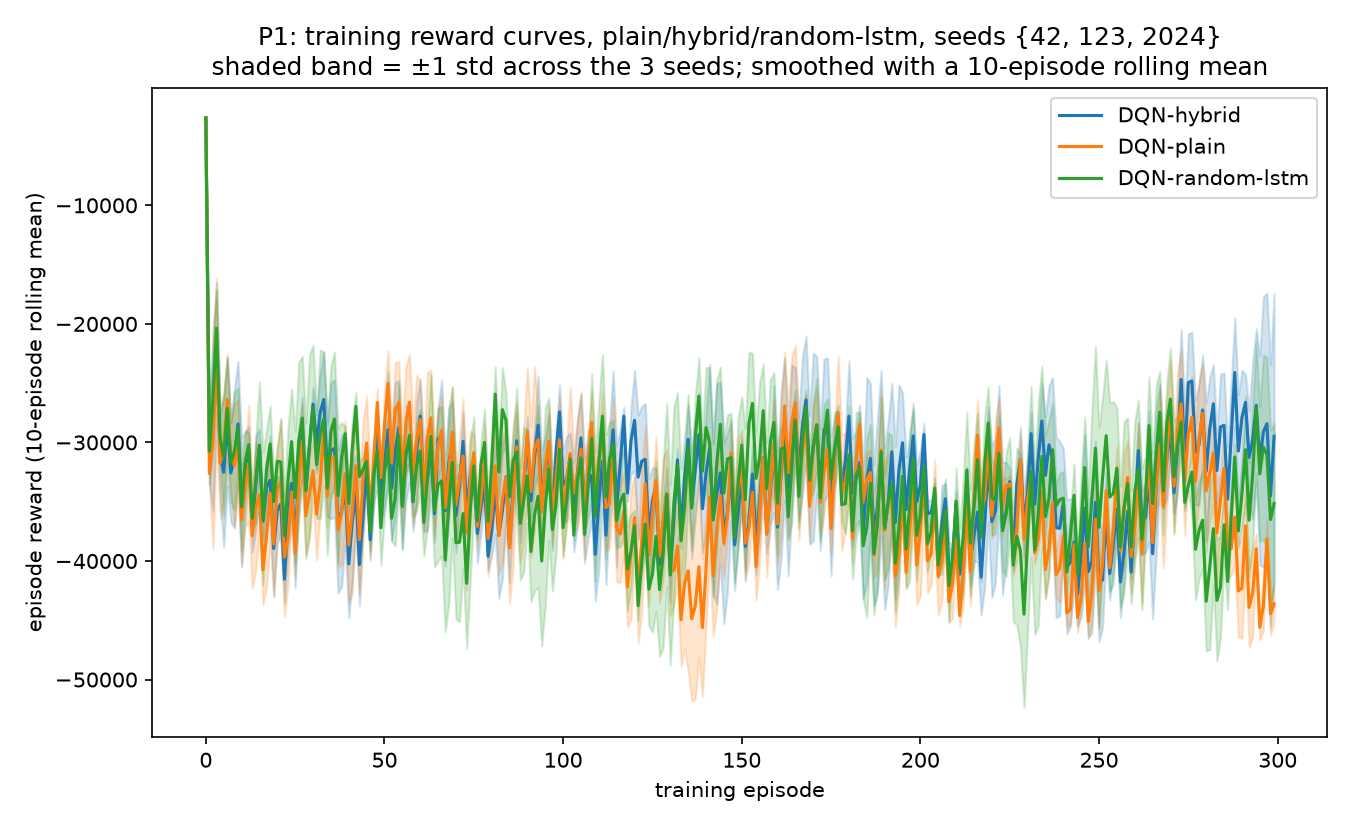

In [17]:
display(Image(filename=str(_OUT_DIR / "P1_reward_curves.png")))

## P2 — Validation reward over episodes

Real data: `runs/*/validation.csv` (`val_mean_reward`, `val_std_reward`), evaluated every 25
episodes (5 validation episodes per point, on the held-out validation scenario SCN-04). The
source files carry 11 points each (episodes 25..275), not 12 — a minor discrepancy from the
methodology note's "25,50,...,300" listing; the plot uses exactly what is on disk.

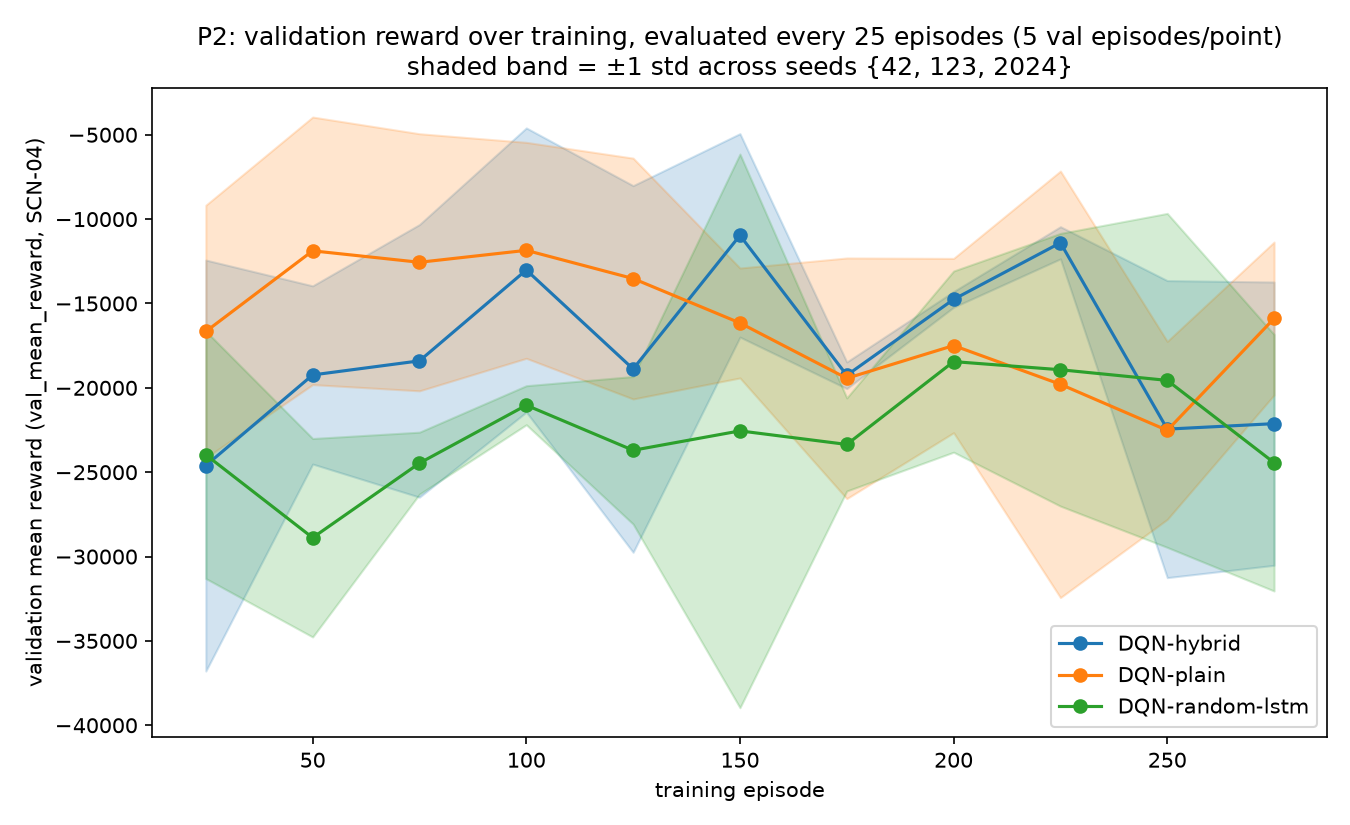

In [18]:
display(Image(filename=str(_OUT_DIR / "P2_validation_reward.png")))

## P3 — Per-movement max wait [PROXY]

**This is a PROXY, not the real plot.** The real P3 needs 12 bars (one per movement) × N
algorithms, built from per-movement waiting time. Inspecting a few lines of
`data/eval/SCN-05_*.jsonl`: each `sim_frame` payload records `{signal: {...}, vehicles: [{id,
lane, movement_id, speed, type, x, y}, ...]}` at 1 Hz — per-vehicle position/speed/lane, but **no
per-movement wait aggregate**. Building the real chart would mean re-deriving waiting time per
movement from raw vehicle trajectories (e.g. thresholding `speed` over time, grouped by
`movement_id`), which is out of scope for this analysis pass (this module reads existing data, it
does not recompute KPIs from 1 Hz traces). The fallback below uses `worst_movement_max_wait` per
controller from `eval_results.csv` — a single worst-movement bar per controller, not all 12.

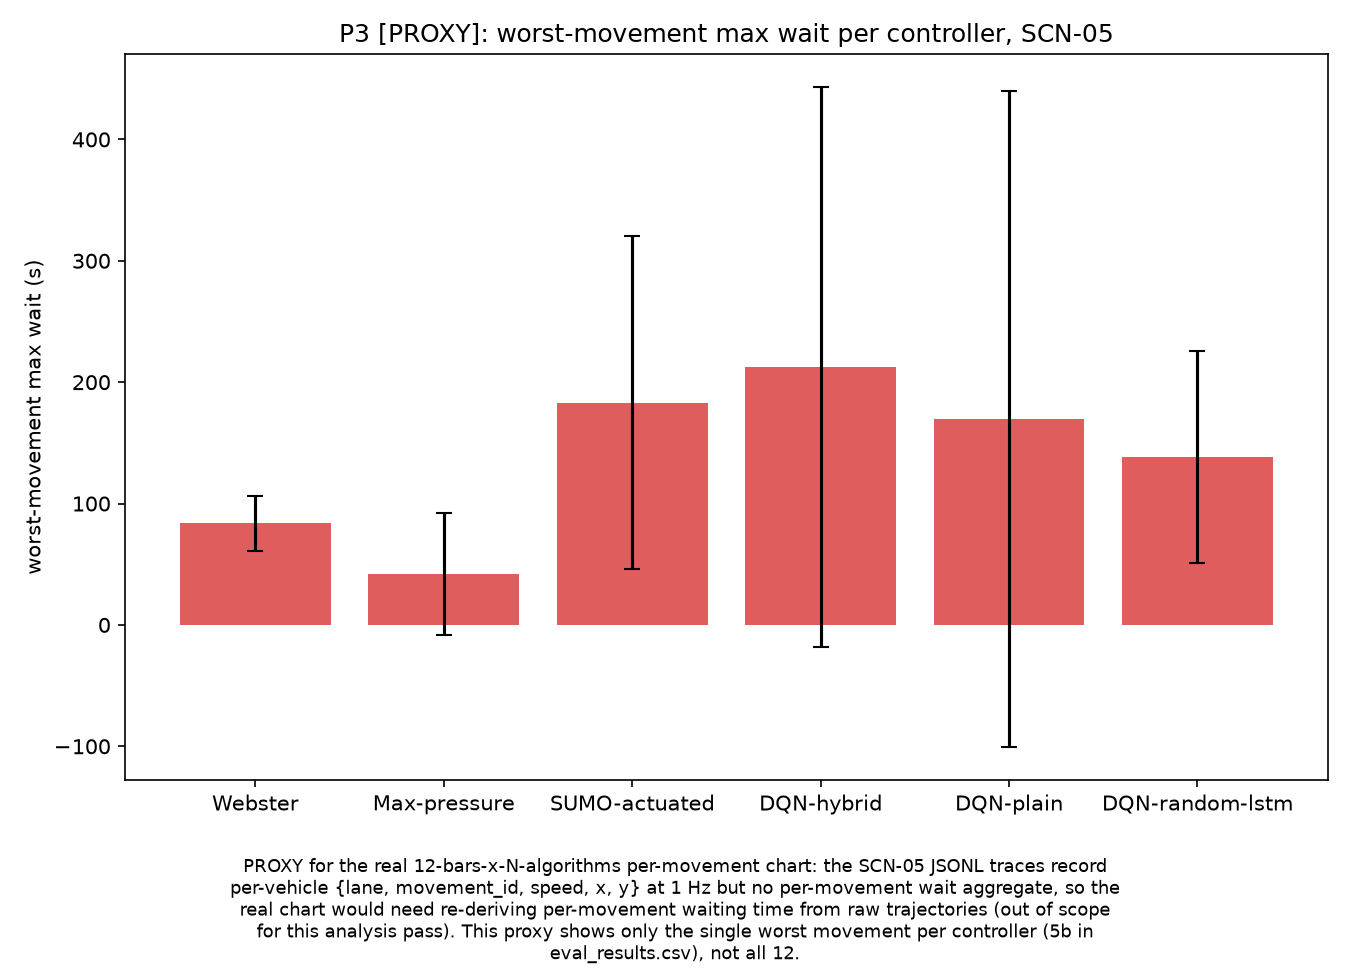

In [19]:
display(Image(filename=str(_OUT_DIR / "P3_per_movement_max_wait_PROXY.png")))

## P4 — KPI distributions (box plot)

Real data: `eval_results.csv`, SCN-05 (the designated test scenario). DQN variants carry the true
n=15 sample; baselines are NOT replicated up to 15 to match — they carry their true n=5 (or fewer
where censored/missing), shown explicitly in each box's label.

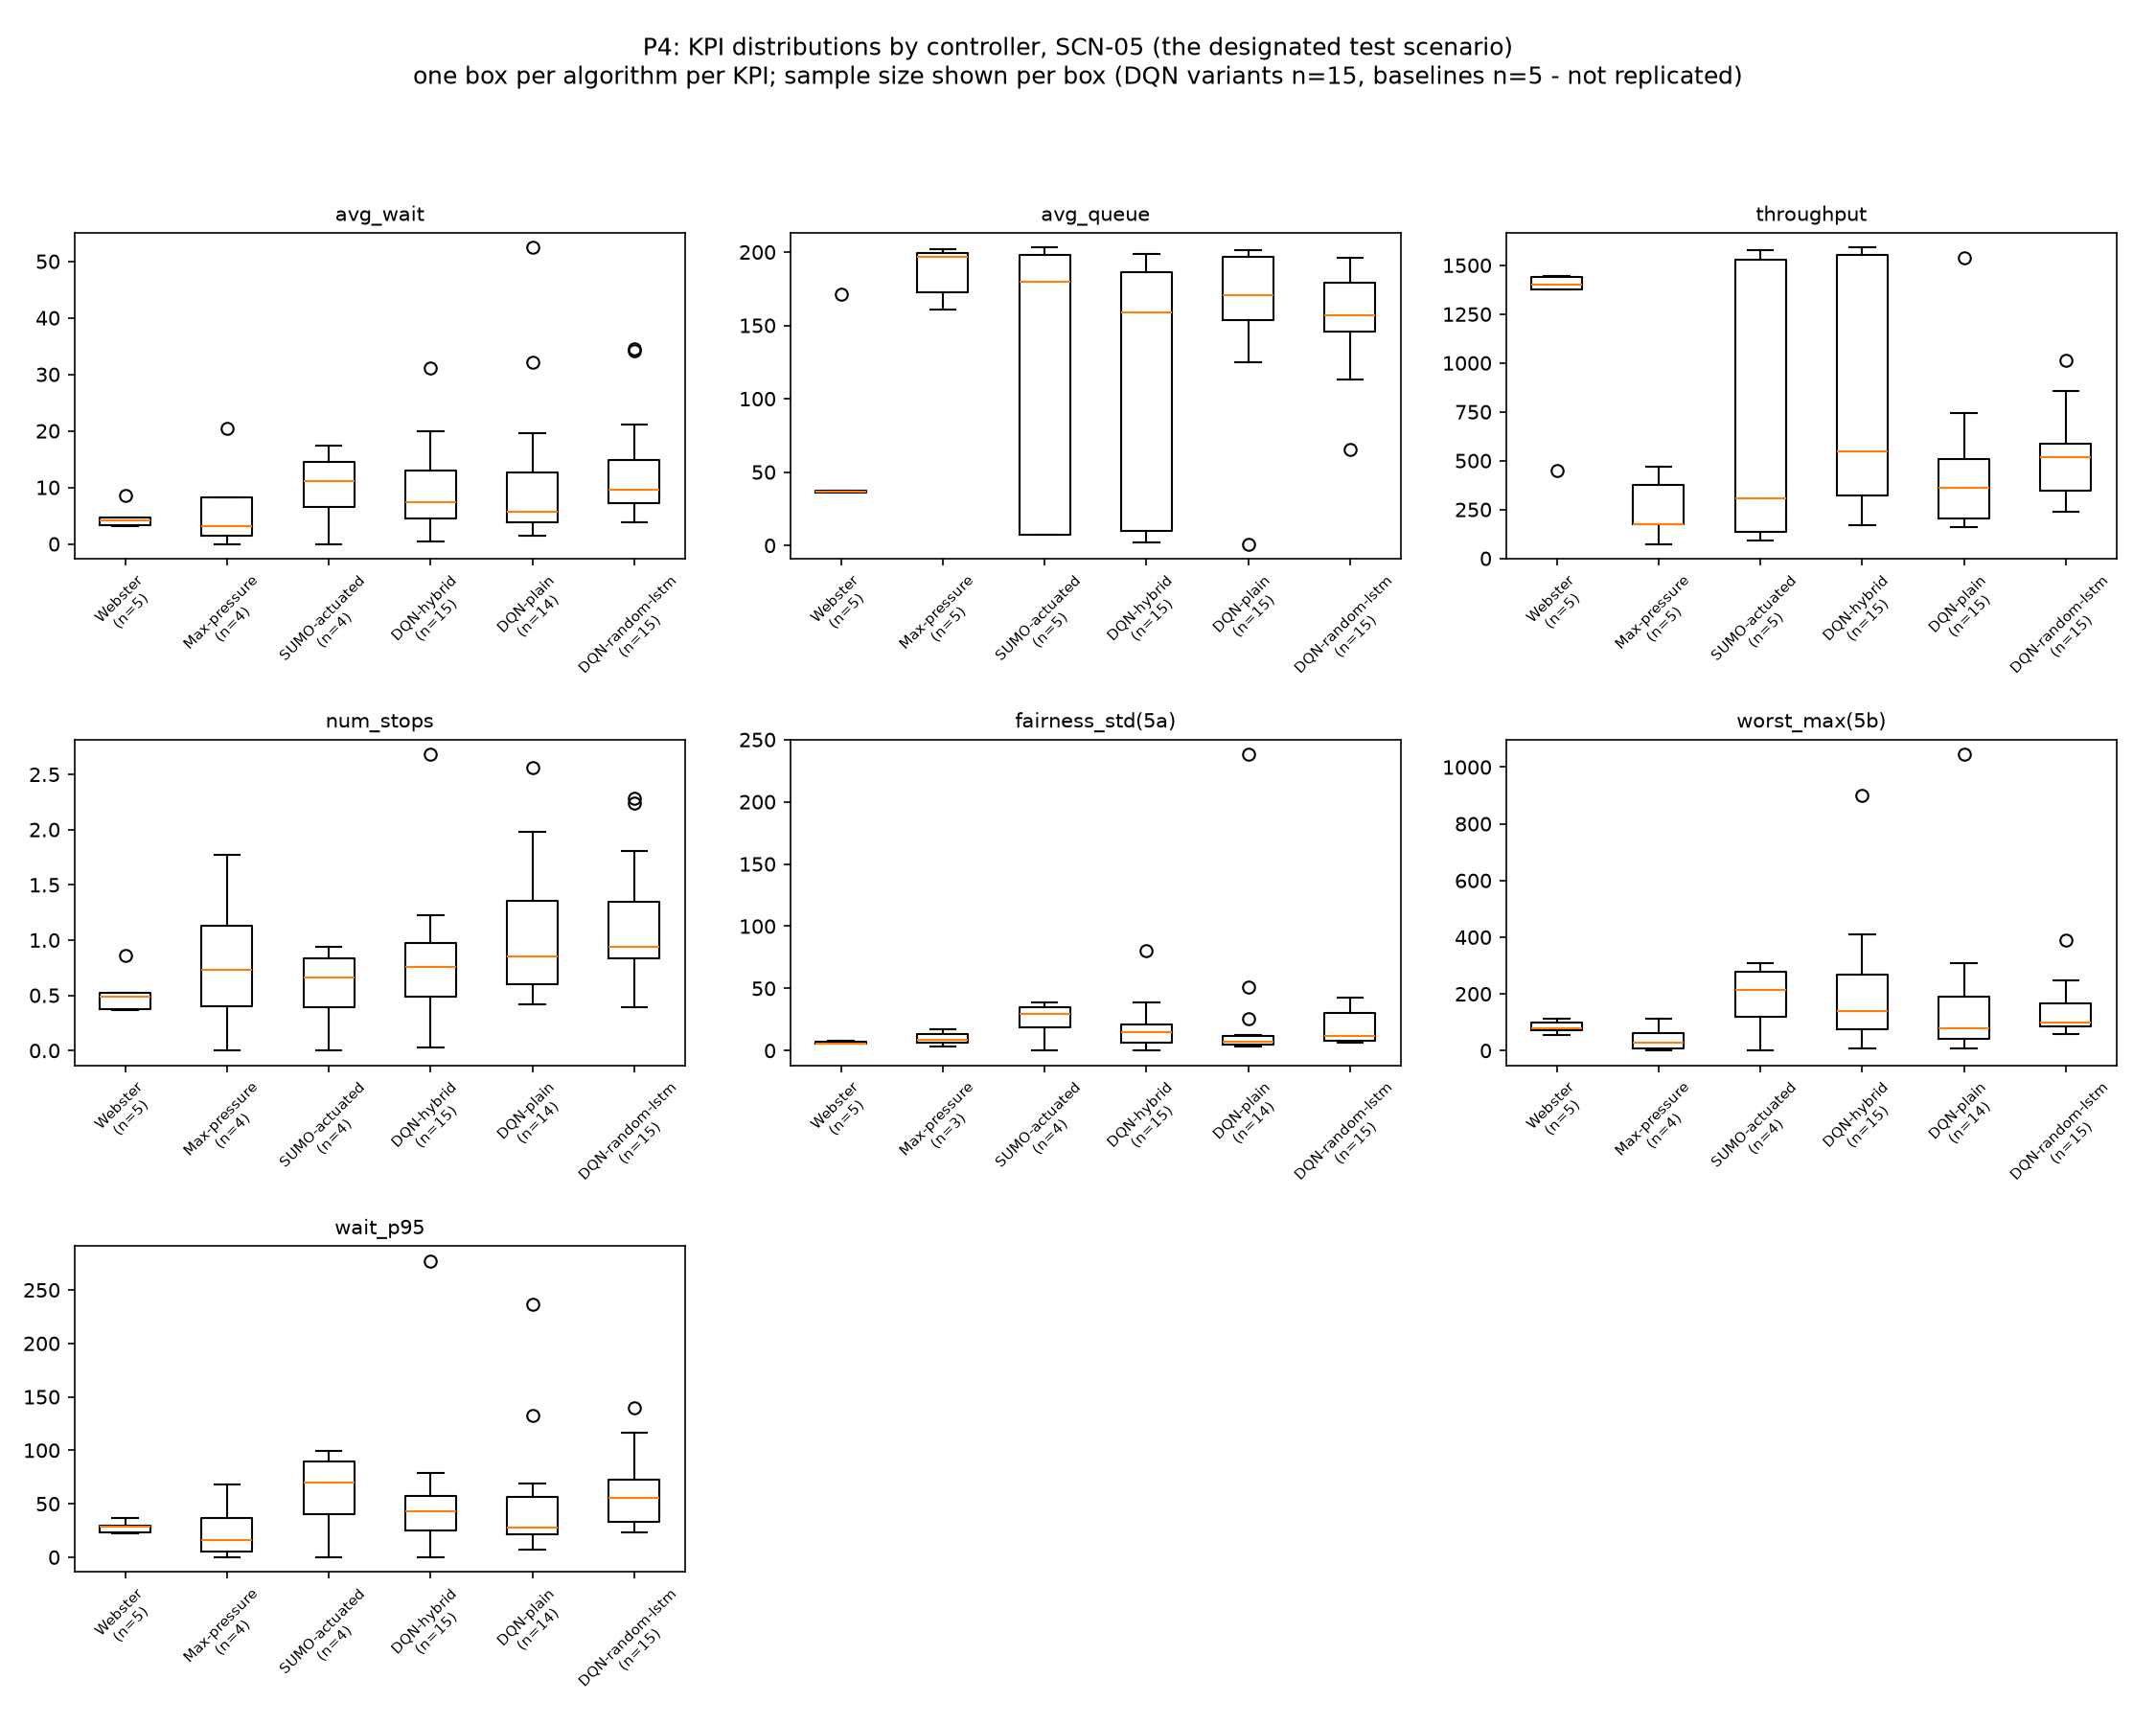

In [20]:
display(Image(filename=str(_OUT_DIR / "P4_kpi_distributions.png")))

## P5 — Forecast accuracy during RL training

Real data: `ss_rolling` from `runs/{hybrid,random-lstm}_seed{42,123,2024}/episodes.csv`. `plain`
has `forecast: false` in its config, so its `ss_rolling` column is entirely empty for all 3 seeds
— it is excluded from this plot, not silently zero-filled. Smoothed with a 20-episode rolling
mean per seed, then linearly interpolated onto a common episode grid to compute the cross-seed
mean/std band (both the smoothing and interpolation are stated here and in the plot caption).
Documents the distribution-shift weakness explicitly: the LSTM was trained offline on
`data_version=data-8eb28eecdefb` and its in-RL skill score visibly drifts as the policy shifts the
state distribution away from that training distribution.

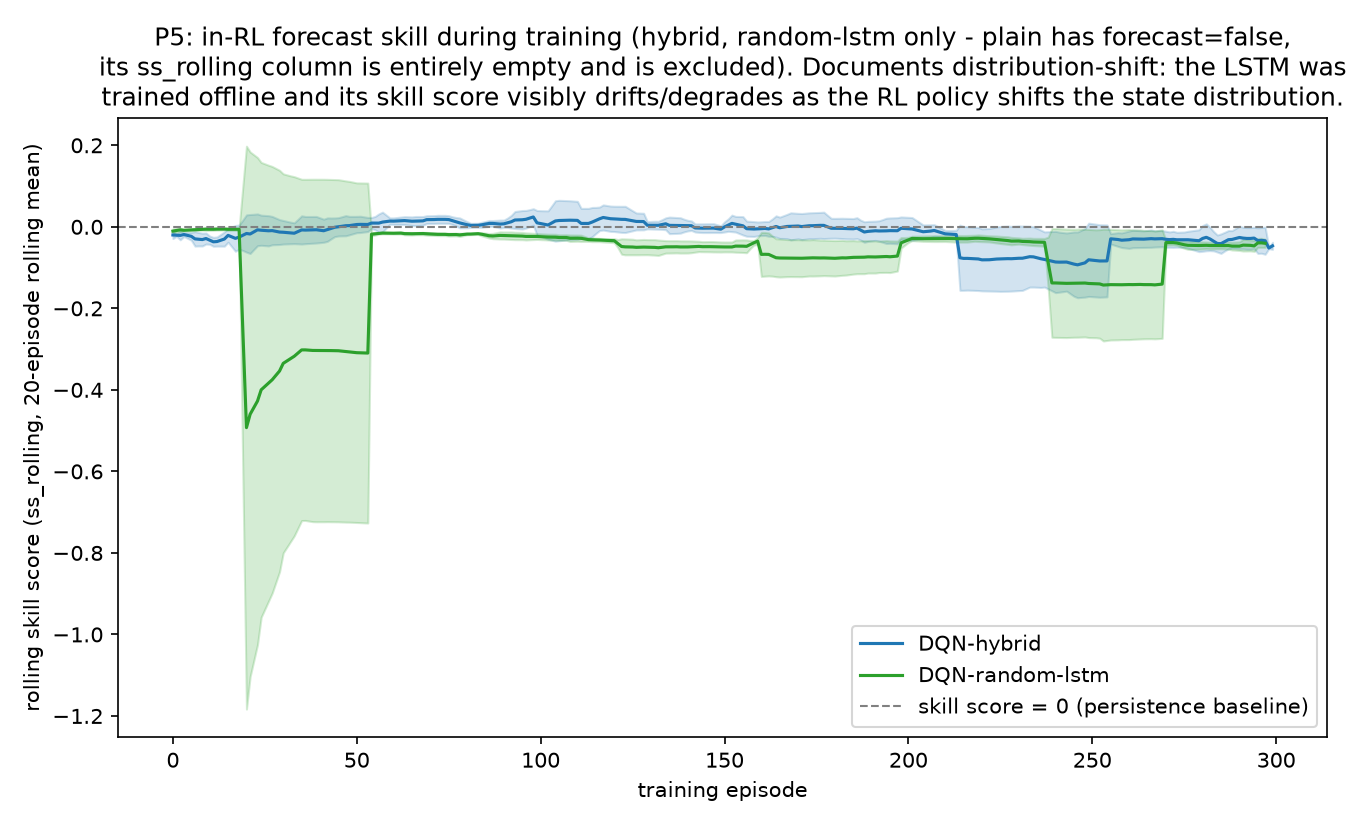

In [21]:
display(Image(filename=str(_OUT_DIR / "P5_forecast_accuracy_training.png")))

## Summary of gaps (stated, not papered over)

- **λ (switch-penalty) sweep {0, 0.05, 0.1, 0.5}:** never run. T2 has no data for it.
- **Wall-clock timing (T4):** never recorded for any of the 9 headline runs.
- **Per-scenario forecast MSE (T3):** not decomposed in the LSTM report jsons; only aggregate
  val/test MSE exists.
- **`departed_count` / `arrived_count` (§8 anti-starvation context):** not present as columns in
  `eval_results.csv`; `gridlock_censored` + its rate is the available substitute context.
- **P3 (per-movement max wait):** the real 12-bar chart needs per-movement wait derived from raw
  1 Hz vehicle traces, which are not pre-aggregated in the JSONL payloads. A proxy is shown
  instead, labeled as such.
- **Webster N/A / `FixedTime-120`:** the rule is implemented in `src/baselines/webster.py`, but no
  scenario in this dataset actually triggers it (all 5 have Y < 0.90).
- **`lstm_version` provenance:** empty in the logged `config.yaml` for hybrid/random-lstm runs;
  recovered here from `forecast_ckpt` instead.

None of these gaps were filled with estimated or fabricated numbers.